## UAS DATA MINING


### Tugas Proyek Akhir: Preprocessing dan Unsupervised Learning (Clustering)

#### NAMA: LINTANG MAULANA YUSUF

#### NIM: 241011401753


#### 1. Pemilihan Dataset: Pilih satu dataset publik (bebas dari Kaggle, UCI Machine Learning Repository, dll) yang relevan untuk kasus pengelompokan (clustering). Pastikan dataset tersebut memiliki kecacatan data (misal: missing values, duplikat, atau format tidak konsisten) agar tahap cleaning dapat dilakukan.

##### Data set nya menggunakan E-Commerce Data: https://www.kaggle.com/datasets/carrie1/ecommerce-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


(541909, 8)

#### 2. Tahap Cleaning Data: Lakukan pra-pemrosesan data yang mencakup minimal:
##### -Penanganan Missing Values (Imputasi atau penghapusan).
##### -Penanganan data duplikat.
##### -Scaling atau Normalization (Standarisasi data numerik).
##### -(Opsional) Penanganan Outlier atau Encoding data kategorikal jika diperlukan.

#### PENANGANAN MISSING VALUES
#### A. Cek Missing Value

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### B. Menghapus Missing Value

In [5]:
df = df.dropna(subset=["CustomerID"])


In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### Penanganan data duplikat.

In [7]:
print("Sebelum :", df.shape)

df = df.drop_duplicates()

print("Sesudah :", df.shape)

Sebelum : (406829, 8)
Sesudah : (401604, 8)


#### Scaling atau Normalization (Standarisasi data numerik).


In [8]:
X = df[['Quantity', 'UnitPrice']]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 3. Implementasi Clustering: Implementasikan salah satu algoritma pengelompokan berikut menggunakan bahasa pemrograman bebas (sangat disarankan Python dengan library seperti Scikit-Learn):
##### - K-Means Clustering
##### - Hierarchical Clustering (Agglomerative)
##### - DBSCAN


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,0


In [21]:
df["Cluster"].value_counts()

Cluster
0    401601
2         2
1         1
Name: count, dtype: int64

### 4. Evaluasi dan Visualisasi: Buatlah visualisasi hasil clustering (misalnya scatter plot 2D/3D) dan berikan evaluasi sederhana (misal menggunakan metode Elbow, Silhouette Score, atau analisis karakteristik setiap cluster).

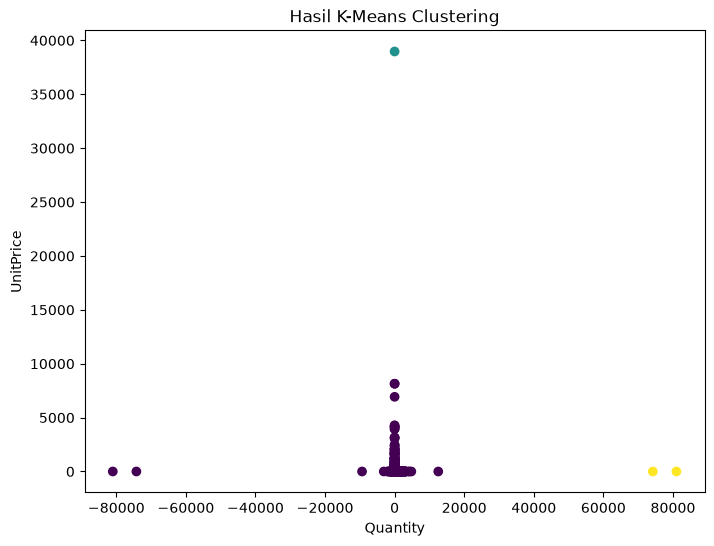

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(df["Quantity"], df["UnitPrice"], c=df["Cluster"])

plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Hasil K-Means Clustering")

plt.show()

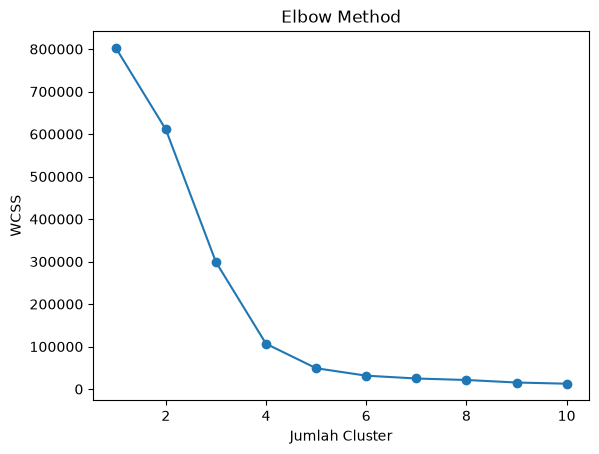

In [24]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# UAS DATA MINING

## Tugas Proyek Akhir: Preprocessing dan Unsupervised Learning (Clustering)

**Nama:** Lintang Maulana Yusuf  
**NIM:** 241011401753

---

# 1. Pemilihan Dataset

Dataset yang digunakan adalah **E-Commerce Data** yang diperoleh dari Kaggle.

Sumber Dataset:
https://www.kaggle.com/datasets/carrie1/ecommerce-data

Dataset ini berisi data transaksi penjualan pada sebuah toko online dengan atribut seperti **InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID,** dan **Country**. Dataset dipilih karena sesuai untuk proses clustering dan memiliki data yang dapat dilakukan tahap preprocessing.

---

# 2. Tahap Cleaning Data

## A. Penanganan Missing Value

Langkah pertama adalah melakukan pengecekan missing value pada setiap kolom menggunakan fungsi `isnull().sum()`.

```python
df.isnull().sum()
```

Selanjutnya dilakukan penghapusan data yang memiliki nilai kosong menggunakan fungsi `dropna()` pada kolom **CustomerID**.

```python
df = df.dropna(subset=["CustomerID"])
```

Kemudian dilakukan pengecekan kembali untuk memastikan tidak ada missing value.

---

## B. Penanganan Data Duplikat

Data duplikat diperiksa menggunakan fungsi `duplicated()`.

```python
df.duplicated().sum()
```

Selanjutnya data duplikat dihapus menggunakan fungsi `drop_duplicates()`.

```python
df = df.drop_duplicates()
```

Jumlah data sebelum dan sesudah proses penghapusan ditampilkan untuk memastikan hasil preprocessing.

---

## C. Scaling Data

Sebelum proses clustering dilakukan, data numerik distandarisasi agar memiliki skala yang sama.

Kolom yang digunakan adalah:

- Quantity
- UnitPrice

Standarisasi dilakukan menggunakan **StandardScaler** dari Scikit-Learn.

```python
X = df[['Quantity','UnitPrice']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

---

# 3. Implementasi Clustering

Pada tugas ini digunakan algoritma **K-Means Clustering**.

Jumlah cluster ditentukan sebanyak **3 cluster**.

```python
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)
```

Hasil clustering kemudian disimpan pada kolom **Cluster** sehingga setiap data memiliki label kelompok.

---

# 4. Evaluasi dan Visualisasi

## A. Visualisasi Hasil Clustering

Hasil clustering divisualisasikan menggunakan **Scatter Plot 2D** dengan atribut **Quantity** sebagai sumbu X dan **UnitPrice** sebagai sumbu Y. Warna yang berbeda menunjukkan kelompok (cluster) yang berbeda.

Visualisasi ini membantu melihat penyebaran data berdasarkan hasil pengelompokan K-Means.

---

## B. Evaluasi Menggunakan Elbow Method

Evaluasi dilakukan menggunakan **Elbow Method**.

Metode ini digunakan untuk membantu menentukan jumlah cluster yang optimal berdasarkan nilai **WCSS (Within Cluster Sum of Squares)**.

Grafik Elbow menunjukkan perubahan nilai WCSS pada setiap jumlah cluster sehingga dapat digunakan sebagai dasar dalam menentukan jumlah cluster yang digunakan pada proses K-Means.

---

# 5. Kesimpulan

Berdasarkan proses yang telah dilakukan, dataset E-Commerce berhasil melalui tahapan preprocessing yang meliputi penanganan missing value, penghapusan data duplikat, dan standarisasi data numerik.

Selanjutnya dilakukan proses clustering menggunakan algoritma **K-Means** dengan **3 cluster**. Hasil clustering berhasil divisualisasikan menggunakan scatter plot dan dievaluasi menggunakan Elbow Method sehingga proses pengelompokan data dapat dilakukan dengan baik.